# Getting Started with Vivarium

Vivarium provides a Pythonic interface for building, inspecting, running, and visualizing multiscale simulations using [process bigraphs](https://github.com/vivarium-collective/process-bigraph).

This notebook walks through the core workflow:
1. Create a Vivarium
2. Define and register a process
3. Build a model by adding processes and state
4. Run a simulation
5. Analyze and visualize results
6. Save and reload

## 1. Create an empty Vivarium

An empty Vivarium initializes a Core with all default types and processes, and displays as a bigraph diagram in Jupyter.

In [1]:
from vivarium import Vivarium

v = Vivarium()
print(v)

module `wholecell.utils._netflow.nf_cplex` not found during dynamic import
module `wholecell.utils.toya` not found during dynamic import
module `genEcoli` not found during dynamic import
Vivarium(time=0.0, state_keys=['emitter', 'global_time'])


## 2. Define a Process

A `Process` is a temporal computation that reads from input ports and writes updates to output ports. Let's define a simple process that increases a float value by a configurable rate.

In [2]:
from process_bigraph import Process

class IncreaseFloat(Process):
    """A process that multiplies its input by a rate each timestep."""
    config_schema = {
        'rate': {
            '_type': 'float',
            '_default': 0.1,
        }
    }

    def inputs(self):
        return {'amount': 'float'}

    def outputs(self):
        return {'amount': 'float'}

    def update(self, state, interval):
        return {'amount': state['amount'] * self.config['rate'] * interval}

## 3. Register and build a model

We pass a `register` function to Vivarium that registers our custom process. Then we add state, add the process, and wire it up.

In [3]:
def register_demo(core):
    """Register our custom process with the core."""
    core.register_link('increase_float', IncreaseFloat)
    return core

# Create a Vivarium with our custom process registered
v = Vivarium(register=register_demo)

# Add some state
v.merge(
    schema={'level': 'float'},
    state={'level': 100.0},
)

# Add the process and wire its ports to the state
v.add_process(
    name='growth',
    process_id='increase_float',
    config={'rate': 0.01},
    inputs={'amount': ['level']},
    outputs={'amount': ['level']},
)

# Display the bigraph diagram
v.diagram()

module `wholecell.utils._netflow.nf_cplex` not found during dynamic import
module `wholecell.utils.toya` not found during dynamic import
module `genEcoli` not found during dynamic import


## 4. Run the simulation

In [4]:
# Run for 100 time units
v.run(100)

# Check the current time
print(f"Simulation time: {v.time}")

Simulation time: 100.0


## 5. Analyze results

Get the timeseries as a dict or a pandas DataFrame, and plot.

In [5]:
# Get timeseries as a DataFrame
df = v.timeseries(as_dataframe=True)
df.head()

,/global_time
0,1.0
1,2.0
2,3.0
3,4.0
4,5.0


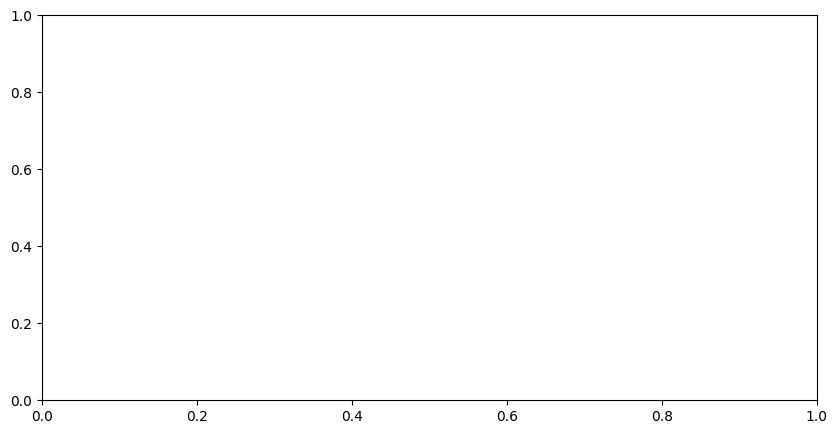

In [6]:
# Plot the timeseries
fig = v.plot()
fig

## 6. Inspect the registry

Browse the available types and processes.

In [7]:
# List registered types
v.types(as_dataframe=True)

,Type
0,node
1,atom
2,empty
3,union
4,tuple
5,boolean
6,or
7,and
8,xor
9,number


In [8]:
# List registered processes
v.processes(as_dataframe=True)

,Process
0,edge
1,process_bigraph.composite.Composite
2,Composite
3,spatio_flux.processes.particles.BrownianMovement
4,BrownianMovement
...,...
82,process_bigraph.protocols.parallel.ParallelPro...
83,ParallelProcess
84,process_bigraph.protocols.rest.RestProcess
85,RestProcess


In [9]:
# Inspect a process's interface
v.process_interface('increase_float')

,section,port,type
0,inputs,amount,float
1,outputs,amount,float


## 7. Save and reload

Save the simulation to a JSON file, then reload it as a new Vivarium.

In [10]:
# Save the current state
v.save('out/demo.json')

# Reload into a new Vivarium
v2 = Vivarium.load('out/demo.json', register=register_demo)
print(v2)
print(f"Loaded state keys: {list(v2.state.keys())}")

module `wholecell.utils._netflow.nf_cplex` not found during dynamic import
module `wholecell.utils.toya` not found during dynamic import
module `genEcoli` not found during dynamic import
Vivarium(time=100.0, state_keys=['level', 'emitter', 'growth', 'global_time'])
Loaded state keys: ['level', 'emitter', 'growth', 'global_time']


## 8. Extend the model

Add a second variable and process to the existing simulation, then run again.

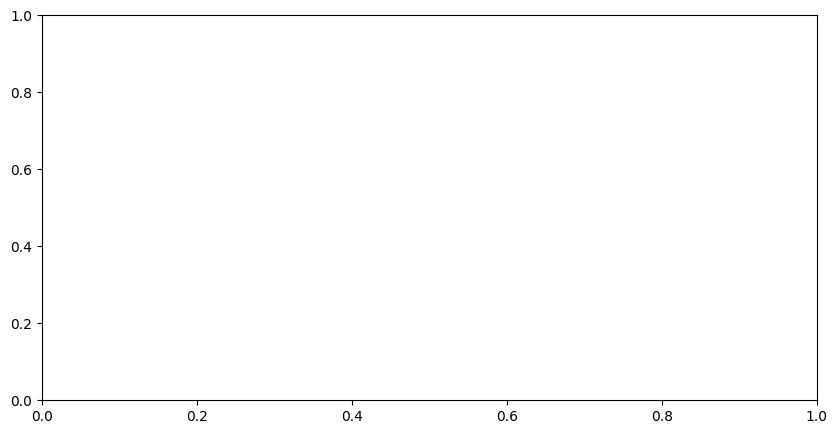

In [11]:
# Add a second variable with a faster decay process
v.merge(schema={'energy': 'float'}, state={'energy': 50.0})

v.add_process(
    name='decay',
    process_id='increase_float',
    config={'rate': -0.02},
    inputs={'amount': ['energy']},
    outputs={'amount': ['energy']},
)

# Reset time and run again
v.set('/global_time', 0.0)
v.run(100)

# Plot both variables
fig = v.plot()
fig